<a href="https://colab.research.google.com/github/cbishop4/MSE7530/blob/main/ClassNotebooks/Day2_F2026_takehome_FTIRinstrumentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font size=6>FTIR Walkthrough  </font>  
MSE/CHE 7530/5995  
Wayne State University, Fall 2026  
Created and taught by Prof. Camille Bishop with material from B. Shepherd & M.K. Bellamy, "A Spreadsheet Exercise to Teach the Fourier Transform in FTIR Spectrometry" in *J. Chem. Ed.* 89, 5, 681-682 (2012). (https://doi.org/10.1021/ed200547a)

In this exercise, you will learn how the FTIR instrument processes a signal into a molecular picture.

## Imports

In [9]:
# the standard cell
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [10]:
!git clone https://github.com/cbishop4/MSE7530.git
from google.colab import drive
drive.mount('/content/drive')

Cloning into 'MSE7530'...
remote: Enumerating objects: 648, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (141/141), done.
remote: Total 648 (delta 66), reused 5 (delta 5), pack-reused 494 (from 2)
Receiving objects: 100% (648/648), 78.39 MiB | 32.24 MiB/s, done.
Resolving deltas: 100% (228/228), done.


ModuleNotFoundError: No module named 'google.colab'

## Theoretical (instrumental) background - Fourier Transform Infrared Spectroscopy
Note: I expect that this won't make much sense at first. Read through it lightly, and my hope is that as you move through the activities, it will make more sense; so, give it a re-read later.

The objective of FTIR is to find which wavelengths of infrared light are absorbed by a sample, which yields information about chemical bond identity and geometry. Today, we will focus on how the instrument interprets a signal. Briefly, a broadband (many-wavelength) source of light is sent to a beam-splitter which directs (ideally) half the light to a stationary mirror, and half the light to a mirror with variable path length. The light recombines and is sent through the sample, where it impinges upon a detector.

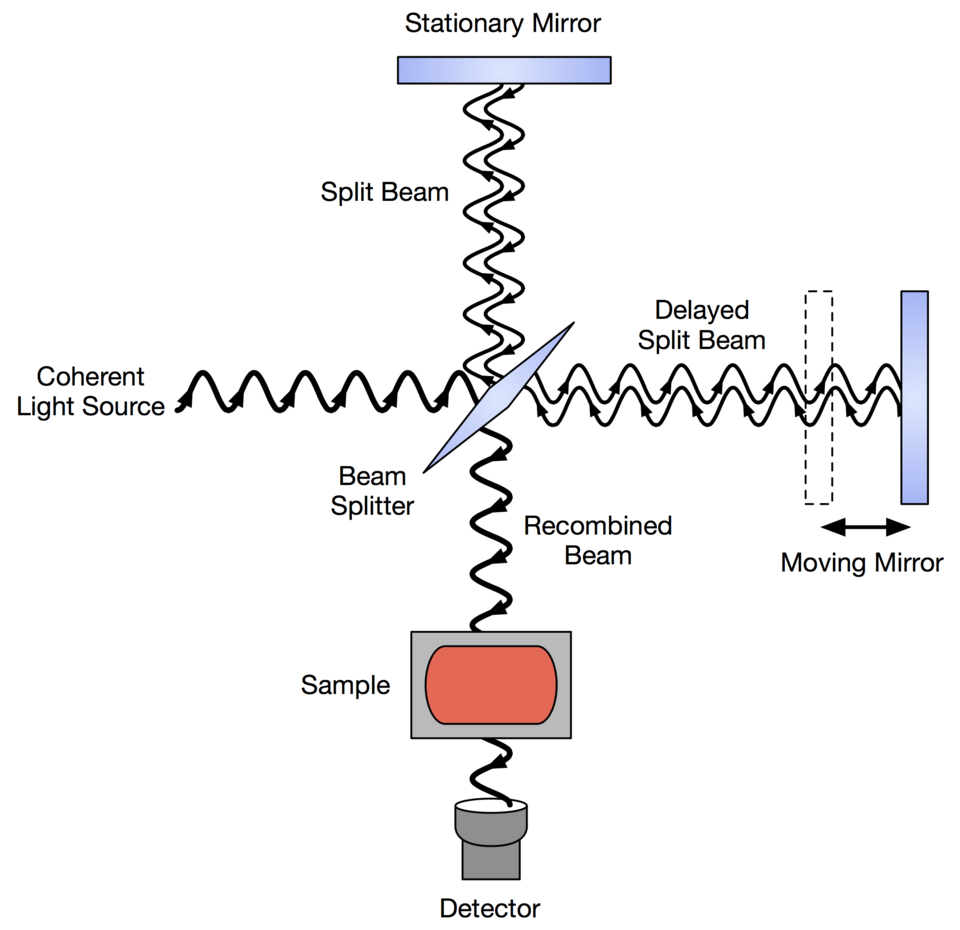

(Credit for above image) By Sanchonx (talk) - I, Sanchonx (talk), created this work entirely by myself., Public Domain, https://commons.wikimedia.org/w/index.php?curid=25333405

The difference in path length from the beamsplitter to each of the two mirrors is defined as the retardance $\delta$. The intensity for a specific wavelength $\lambda$ at a given $\delta$ is given by **Equation 1**:  
$I(\delta)={\frac{I_{0}}{2}}[1+cos(\frac{2 \pi \delta}{\lambda})]$  
For a specific value of $\delta$, certain wavelengths will have a maximum in intensity, while others will have minima.

Constructive interference occurs when the difference in path length is an integer multiple of the wavelength:  
$\delta=2x=n\lambda$ (**Equation 2**)  
Destructive interference happens when a crest meets a trough - that is, when the path length difference is an integer and a half multiple of the wavelength:  
$\delta=\lambda(n+\frac{1}{2})$ (**Equation 3**)

The total intensity of light in the detector at a given mirror distance (related to $\delta$) can be found by summing over $M$ wavelengths as shown in **Equation 4**:  
$I_T(\delta)=\sum\limits_{m=1}^{M}{\frac{I_{m,0}}{2}}[1+cos(\frac{2 \pi \delta}{\lambda_{m}})]$

To generate an interferogram, this is performed for many values of $\delta$. Pay attention to the fact that there are a few different sums going on; there are m wavelengths,

All wavelengths are collected simultaneously

## Simulating the intensity as a function of $\delta$ for light with a $\lambda$ of $2~\mu m$  
Goal: For a *single* wavelength of light, we want to know how the intensity will vary as a function of the path length difference at different values of the moving mirror position. We will be using the equation:  
$I(\delta)={\frac{I_{0}}{2}}[1+cos(\frac{2 \pi \delta}{\lambda})]$  
*Check your understanding*: why are we using equation 1 (no summation) rather than equation 4 (with the summation)? Answer is in white text; highlight once you have guessed.
<font color='white'>Answer: The summation in equation 4 is to sum over multiple wavelengths; we are only using one wavelength.

Here we will use the NumPy package to perform calculations on a set of wavelengths. We will start by specifying a NumPy array of different values of $\delta$ using the linspace function, which generates evenly spaced numbers over a specified interval. (https://numpy.org/doc/stable/reference/generated/numpy.linspace.html)

In [ ]:
deltas = np.linspace(start=-10, stop=10, num=50) # generates 50 evenly spaced numbers from -10 to 10
deltas = np.linspace(-10, 10, 50) # this is equivalent to above; above we have just explicitly defined the input variables

In [ ]:
print(deltas) # this is what we generated with the above functions

[-10.          -9.59183673  -9.18367347  -8.7755102   -8.36734694
  -7.95918367  -7.55102041  -7.14285714  -6.73469388  -6.32653061
  -5.91836735  -5.51020408  -5.10204082  -4.69387755  -4.28571429
  -3.87755102  -3.46938776  -3.06122449  -2.65306122  -2.24489796
  -1.83673469  -1.42857143  -1.02040816  -0.6122449   -0.20408163
   0.20408163   0.6122449    1.02040816   1.42857143   1.83673469
   2.24489796   2.65306122   3.06122449   3.46938776   3.87755102
   4.28571429   4.69387755   5.10204082   5.51020408   5.91836735
   6.32653061   6.73469388   7.14285714   7.55102041   7.95918367
   8.36734694   8.7755102    9.18367347   9.59183673  10.        ]


Now we will write a function that uses the above equation to calculate intensity as a function of wavelength and path difference (retardance). This also makes use of NumPy's cosine function and its definition of $\pi$; note that this function must use **radians**.

In [ ]:
def I_delta(
    retardance, # difference in path length, driving phase shift
    wl,         # wavelength
    I_0 = 1.0   # intensity of incoming light
  ):
  return (I_0/2) * (1 + np.cos(2.*np.pi*retardance/wl))

We can use that function to calculate the intensity at a single value of the path difference. Note that $\delta$ and $\lambda$ must have the same units :

In [ ]:
I_4 = I_delta(
    retardance = 4.8,
    wl = 2
)
print(f'Intensity is {I_4}')

Intensity is 0.09549150281252644


Of course, this isn't that meaningful for a single number. We can use the function in the same way on a whole NumPy array to return another NumPy array with all of the calculated values. We can then plot the data using matplotlib.

Text(0, 0.5, '$I(\\delta)$')

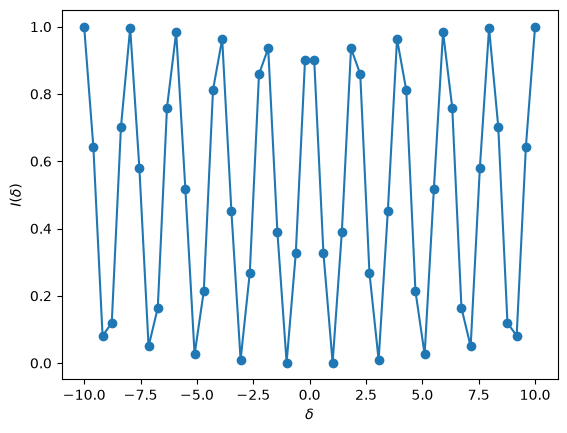

In [ ]:
I_2um = I_delta(
    retardance = deltas,
    wl = 2
)
# plot the data
plt.plot(deltas, I_2um,'-o')
plt.xlabel(r'$\delta$')
plt.ylabel(r'$I(\delta)$')

Oops! that doesn't look much like a cosine, which we know we should have based on the function. In this case, we specified too few points in linspace, so let's try that again.

In [ ]:
deltas_hires = np.linspace(start=-10, stop=10, num=500)

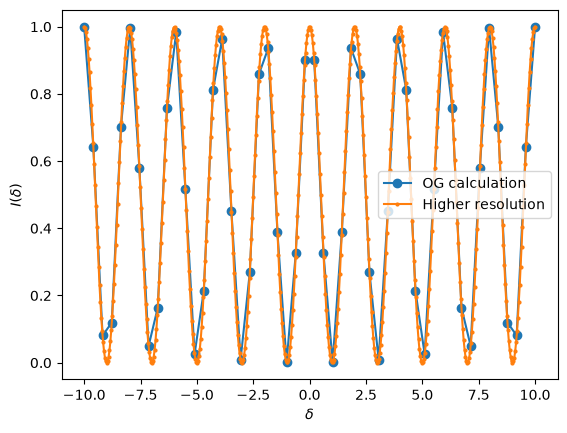

In [ ]:
I_2um_hires = I_delta(retardance=deltas_hires, wl=2)
# plot the data
plt.plot(deltas, I_2um,'-o',label='OG calculation')
plt.plot(deltas_hires, I_2um_hires,'-o',markersize=2,label='Higher resolution')
plt.xlabel(r'$\delta$')
plt.ylabel(r'$I(\delta)$')
plt.legend()

Now, an FTIR instrument simultaneously collects all wavelengths at once. Let's add in some $2.1~\mu m$ light.

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2780/2148464483.py:11: SyntaxWarning: invalid escape sequence '\d'
  ax[0].set_title('$I(\delta)$ for 2 different wavelengths')
/tmp/ipykernel_2780/2148464483.py:17: SyntaxWarning: invalid escape sequence '\d'
  ax[1].set_title('Sum of $I(\delta)$ for 2 different wavelengths')


Text(0.5, 1.0, 'Sum of $I(\\delta)$ for 2 different wavelengths')

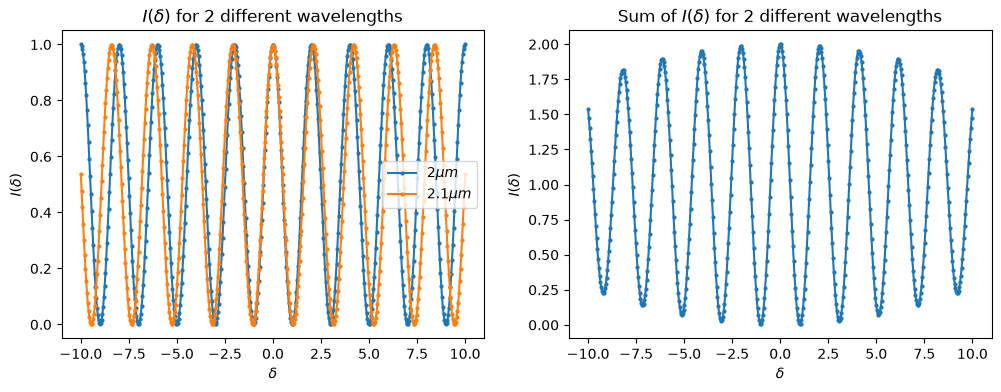

In [ ]:
I_2um_hires = I_delta(retardance=deltas_hires, wl=2)     # 2 um wavelength
I_2p1um_hires = I_delta(retardance=deltas_hires, wl=2.1) # 2.1 um wavelength


fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(deltas_hires, I_2um_hires,  '-o',markersize=2,label= r'$2 \mu m$')
ax[0].plot(deltas_hires, I_2p1um_hires,'-o',markersize=2,label= r'$2.1 \mu m$')
ax[0].set_xlabel(r'$\delta$')
ax[0].set_ylabel(r'$I(\delta)$')
ax[0].legend()
ax[0].set_title('$I(\delta)$ for 2 different wavelengths')
# now we can add the two together to see what the FTIR would see if it measured 2 wavelengths
summed = I_2um_hires + I_2p1um_hires
ax[1].plot(deltas_hires, summed,'-o',markersize=2)
ax[1].set_xlabel(r'$\delta$')
ax[1].set_ylabel(r'$I(\delta)$')
ax[1].set_title('Sum of $I(\delta)$ for 2 different wavelengths')

Above, we did NumPy array math to add together the two arrays. When two arrays are added in NumPy, they will add element by element.

We can combine the power of NumPy with a for loop to sum up more wavelengths automatically. Here we will do this for 50 wavelengths from 1.5 to 2.5 $\mu$m.

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2780/2333259719.py:12: SyntaxWarning: invalid escape sequence '\d'
  plt.title('Sum of $I(\delta)$ for 40 different wavelengths')


Text(0.5, 1.0, 'Sum of $I(\\delta)$ for 40 different wavelengths')

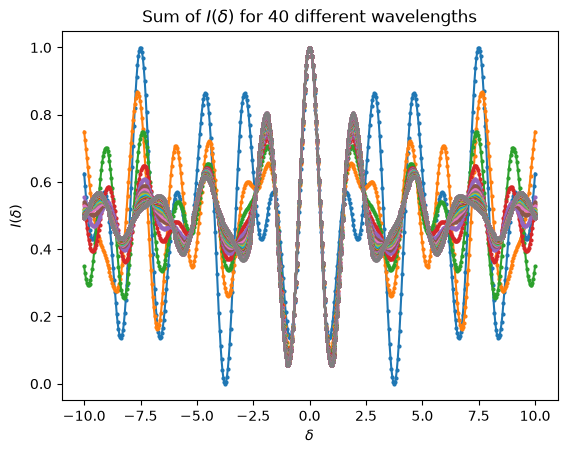

In [ ]:
for i in range(2,40):
  spectrum = np.linspace(1.5, 2.5, i) # sets a variable to a numpy array with 40 evenly spaced elements from 1.5 to 2.5
  tot_signal = np.zeros(len(deltas_hires)) # this initializes a numpy array with the number of elements calculated at each value, all zeros; needed for the next operation
  for s in spectrum: # will move through each of the 40 elements.
    tot_signal = tot_signal + I_delta(retardance=deltas_hires, wl=s)
    # above line calculates the expected signal at each wavelength, and then adds it to the overall sum

  tot_signal = tot_signal /i
  plt.plot(deltas_hires, tot_signal,'-o',markersize=2)
plt.xlabel(r'$\delta$')
plt.ylabel(r'$I(\delta)$')
plt.title('Sum of $I(\delta)$ for 40 different wavelengths')

Something we will discuss in class - how does the resolution of the wavelengths impact the shape of the interferogram, if at all?

For example, what if we had done the above with only 3 values of the wavelength - 1.5, 2.0, and 2.5 $\mu$m? 400 values from 1.5 to 2.5? You have two tasks:


1. Describe how you could test this by breaking down the above algorithm and conceptually modifying it. Try to prompt your algorithm into Gemini to make a graph that can answer the question.

2. Be ready to answer the question: Does it affect the interferogram, and how? Physically, why does this make sense?

<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2780/4022814499.py:20: SyntaxWarning: invalid escape sequence '\d'
  plt.title('Sum of $I(\delta)$ for 40 different wavelengths')


Text(0.5, 1.0, 'Sum of $I(\\delta)$ for 40 different wavelengths')

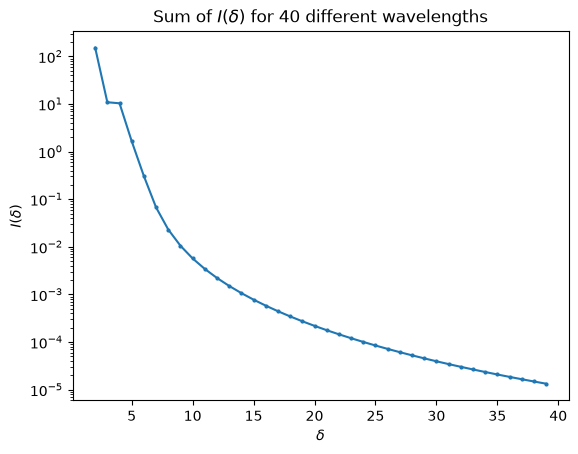

In [ ]:
ranger = range(2,40)
signals = [np.zeros(len(deltas_hires))] # this initializes a numpy array with the number of elements calculated at each value, all zeros; needed for the next operation

for _spectrum in [np.linspace(1.5, 2.5, _i) for _i in ranger]:
  _sig = np.zeros(len(deltas_hires))
  for s in _spectrum:
    _sig = _sig + I_delta(retardance=deltas_hires, wl=s)
  signals.append(_sig / len(_spectrum))

def r2(new, old):
  ss_res = np.sum((new - old)**2)
  # ss_tot = np.sum((old - old.mean())**2)
  return 1 - ss_res #/ ss_tot

r2_vals = [r2(signals[j], signals[j-1]) for j in range(1, len(signals))]

plt.semilogy(ranger, 1-np.array(r2_vals),'-o',markersize=2)
plt.xlabel(r'$\delta$')
plt.ylabel(r'$I(\delta)$')
plt.title('Sum of $I(\delta)$ for 40 different wavelengths')

A Fourier tranform breaks down a signal into its constituent frequencies. In the remainder of this activity, you will do that in detail, building to the analysis of a real interferogram.

In the above, we used $I_0=1$ arbitrarily for all wavelengths. In reality, what we want to measure in FTIR is how the absorption intensity varies as a function of wavelength, so what we want to determine is the $I_0$ values, since they hold the chemical information of the sample.

## Walkthrough - FTIR Exercise
The material for this is adapted from B. Shepherd & M.K. Bellamy, "A Spreadsheet Exercise to Teach the Fourier Transform in FTIR Spectrometry" in *J. Chem. Ed.* 89, 5, 681-682 (2012). (https://doi.org/10.1021/ed200547a)

<font size=4>**Defining instrumental parameters, the sampling interval, and math behind the Interferogram generation and apodization** </font>  
The "experimental details" of the spectrometer we will "use" (which would be determined by the instrument you are using) are:  
Resolution: $16~cm^{-1}$

Wavenumber range of spectrometer: $3200~cm^{-1}$ to $470~cm^{-1}$  
We will collect 989 data points in our interferogram; this would be the total number of distinct mirror distances.
We calculate our sampling interval, $h$, based on the wavelength of the calibration laser

In [12]:
lambda_HeNe = 632.8 # nm
h_cm = lambda_HeNe * 10**-7
print(f'The sampling interval is {h_cm} cm')

The sampling interval is 6.327999999999999e-05 cm


We collect a data point every $6.328 \times 10^{-5}$ cm that the mirror slides.

### Section 1: Principles and Apodization

Using the principles of Fourier transforms, the intensity as a function of retardation over a series of wavelengths (where $\overline{\nu}_{N}$ is the wavenumber equivalent to $\frac{1}{\lambda}$) (**Equation 5**):  
<font size=3>$I(\delta_{total})=B_{1}cos(2\pi\overline{\nu}_{1}\delta) + B_{2}cos(2\pi\overline{\nu}_{2}\delta) + ... + B_{N}cos(2\pi\overline{\nu}_{N}\delta)$  
Note that this is an alternate form of Equation 4.

**Apodization** is essential to deal with real data. A true Fourier transform requires data collection from $\delta = -\infty$ to $+\infty$, but this is not possible on a real instrument. Additionally, for a real instrument, the signal will decay as the mirror moves further from the beamsplitter. **Apodization is a mathematical process that makes an interferogram recorded at finite retardation diminish in a way that mimics an interferogram recorded to infinite retardation.**  
The Apodization function is given by (**Equation 6**):  
$A(\delta)=\frac{1}{2}[1 + cos(\frac{\pi \delta}{\Delta_{max}})]$
Where $\Delta_{max}$ is the total retardation needed to collect a spectrum at a given resolution, and is equal to $\frac{1}{resolution}*k_{max}$ ( $k_{max}=n_{points}-1$)

A proper interferogram must be apodized, and is therefore given by $I(\delta)A(\delta)$
Note that NumPy arrays are set up perfectly for this, as they will multiply number-by-number.

#### Starting with a single wavenumber: $1500 cm^{-1}$  
The measured intensity from the spectrum, which we will refer to as $B$, for this wavenumber is $0.8$. With the single wavelength, Equation 5 reduces to  
$I(\delta)=0.8*cos(2\pi*1500*\delta)$  
We will calculate $I(\delta)$, $A(\delta)$, and $I(\delta)A(\delta)$ for the single-wavelength case.

1. Specify all constants and arrays you will need. $\delta = kh$, where $k$ equals the number of data points, and $h$ is the sampling interval. The first value of $k$ is $0$ (i.e., $k_{max}=n_{points}-1$)

In [13]:
h_cm = lambda_HeNe * 10**-7
ks = np.linspace(0,988,num=989,dtype=int)
deltas = ks * h_cm
B_1 = 0.8
wavenumber = 1500 # inv cm
Delta_max = (1/16) * ks[-1] # cm , indexing -1 turns up the last value in the array

2. Calculate $A(\delta)$ and $I(\delta)$ and save them as variables (these variables will be numpy arrays)

In [14]:
A_delta = 0.5 * (1 + np.cos(np.pi * deltas / (ks[-1]*h_cm)))
I_delta = B_1 * np.cos(2 * np.pi * wavenumber * deltas)

3. Calculate $A(\delta)I(\delta)$ and save as a variable (again a numpy array)

In [15]:
Ap_I = A_delta * I_delta

4. Plot the 3 quantities. I am leaving this one blank so that you can try to use Gemini to plot; plotting takes a gross amount of code and I'd rather you not waste your time on it.  
Here is the prompt I fed to Gemini to get a good plot:  "Can you plot the 3 quantities above - the intensity, the apodization function, and the apodized spectrum - on three separate graphs?" Try this one, or try your own.

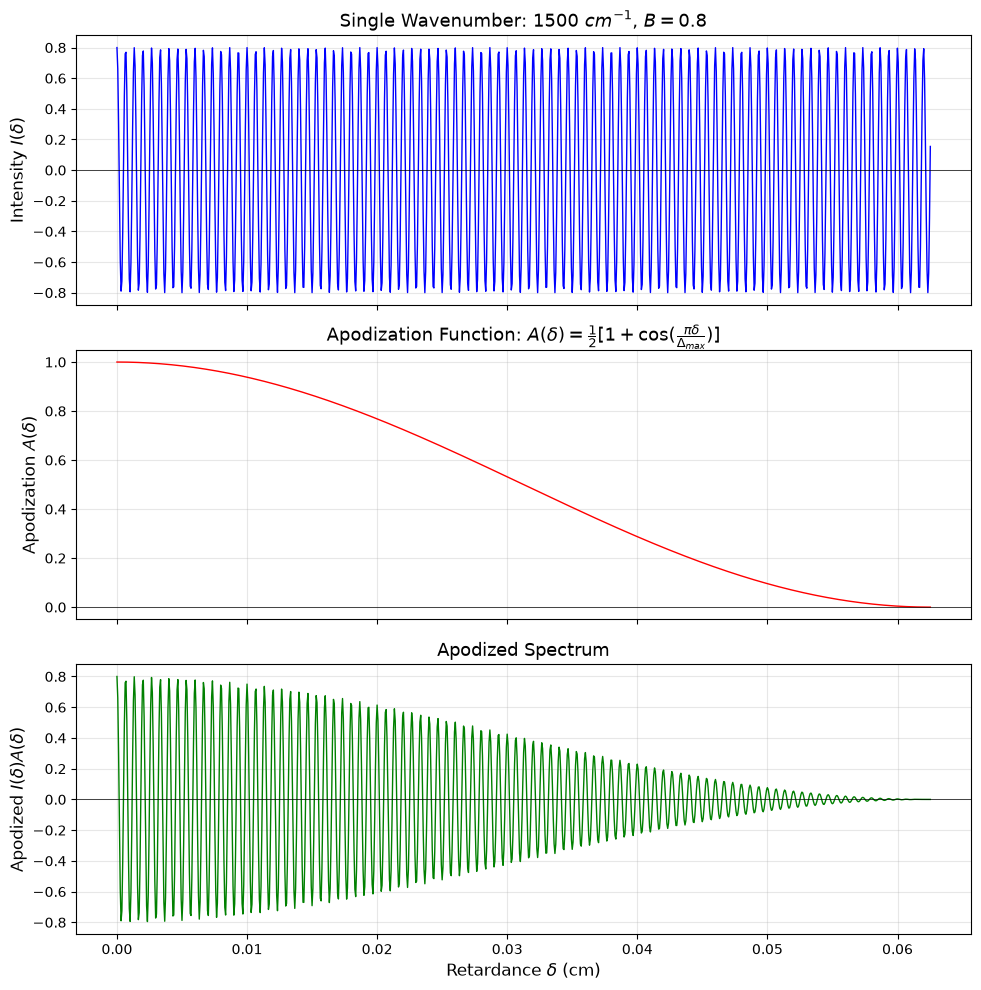

In [16]:
# Plot the three quantities on separate subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# 1. Intensity I(δ)
axes[0].plot(deltas, I_delta, color='blue', linewidth=1.0)
axes[0].set_ylabel('Intensity $I(\\delta)$', fontsize=12)
axes[0].set_title('Single Wavenumber: $1500~cm^{-1}$, $B = 0.8$', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='black', linewidth=0.5)

# 2. Apodization function A(δ)
axes[1].plot(deltas, A_delta, color='red', linewidth=1.0)
axes[1].set_ylabel('Apodization $A(\\delta)$', fontsize=12)
axes[1].set_title('Apodization Function: $A(\\delta) = \\frac{1}{2}[1 + \\cos(\\frac{\\pi \\delta}{\\Delta_{max}})]$', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='black', linewidth=0.5)

# 3. Apodized spectrum I(δ)A(δ)
axes[2].plot(deltas, Ap_I, color='green', linewidth=1.0)
axes[2].set_xlabel('Retardance $\\delta$ (cm)', fontsize=12)
axes[2].set_ylabel('Apodized $I(\\delta)A(\\delta)$', fontsize=12)
axes[2].set_title('Apodized Spectrum', fontsize=13)
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

<font color=blue>What do you notice about the shape of the graphs? We will discuss in class.

#### Moving to 2 wavenumbers: $1500 cm^{-1}$  and $3000 cm^{-1}$.
Now that we added a second wavenumber, there is another B coefficient for the measured intensity. Here, we now have $B_{1} = 0.8$ and $B_{2}=0.5$, corresponding to the two wavenumbers, respectively.  
Equation 1 now becomes:  
$I(\delta) = 0.8 * cos(2\pi * 1500 * \delta) + 0.5 * cos(2\pi * 3000 * \delta)$  
Where $\delta$ is the retardance.

The biggest coding difference here is that we need to start using numpy arrays. One way to intialize them is the following:

1. Specify parameters

In [17]:
Bs = np.array([0.8,0.5])
wns = np.array([1500,3000])

In [18]:

h_cm = 6.328e-5 #cm (from above)
ks = np.linspace(0,988,989)
deltas = ks * h_cm
# removed the previous single-valued B1 and wavenumber
Delta_max = (1/16) * ks[-1] # cm

2. Calculate $A(\delta)$ and $I(\delta)$ and save them as variables (these variables will be numpy arrays).

In [19]:

I_delta = np.zeros(len(ks))
for i in range(len(Bs)):
  I_delta += Bs[i] * np.cos(2 * np.pi * wns[i] * deltas)
A_delta = 0.5 * (1 + np.cos(np.pi * deltas / (ks[-1]*h_cm)))

3. Calculate $A(\delta)I(\delta)$ and save as a variable (again a numpy array)

In [20]:
# your code here
Ap_I = A_delta * I_delta

4. Plot the 3 quantities; again, use Gemini to make the code. Afterwards, examine the code and see what it does to plot things.

#### <font color='blue'> Your turn: calculate $I(\delta), A(\delta), and~ I(\delta)A(\delta)$ for a three-wavelength case, where $B_{1}$, $B_{2}$, and $B_{3}$ are equal to $0.8$, $0.5$, and $0.7$ for $1500$, $3000$, and $1000~cm^{-1}$, respectively. Note that the wavenumbers are not in sequential order; it does not matter.

1. Set up initial parameters

In [21]:
# Three-wavelength parameters
Bs = np.array([0.8, 0.5, 0.7])
wns = np.array([1500, 3000, 1000])  # wavenumbers in cm⁻¹ (not in sequential order)

h_cm = 6.328e-5  # cm (from above)
ks = np.linspace(0, 988, 989)
deltas = ks * h_cm
Delta_max = (1/16) * ks[-1]  # cm

In [ ]:
# Parameters already defined above (h_cm, ks, deltas, Delta_max)

2. Calculate $A(\delta)$ and $I(\delta)$ and save them as variables (these variables will be numpy arrays).

In [22]:
I_delta = np.zeros(len(ks))
for i in range(len(Bs)):
    I_delta += Bs[i] * np.cos(2 * np.pi * wns[i] * deltas)
A_delta = 0.5 * (1 + np.cos(np.pi * deltas / (ks[-1]*h_cm)))

3. Calculate $A(\delta)I(\delta)$ and save as a variable (again a numpy array)

In [23]:
Ap_I = A_delta * I_delta

4. Plot, and be ready to discuss the plot appearance in class.

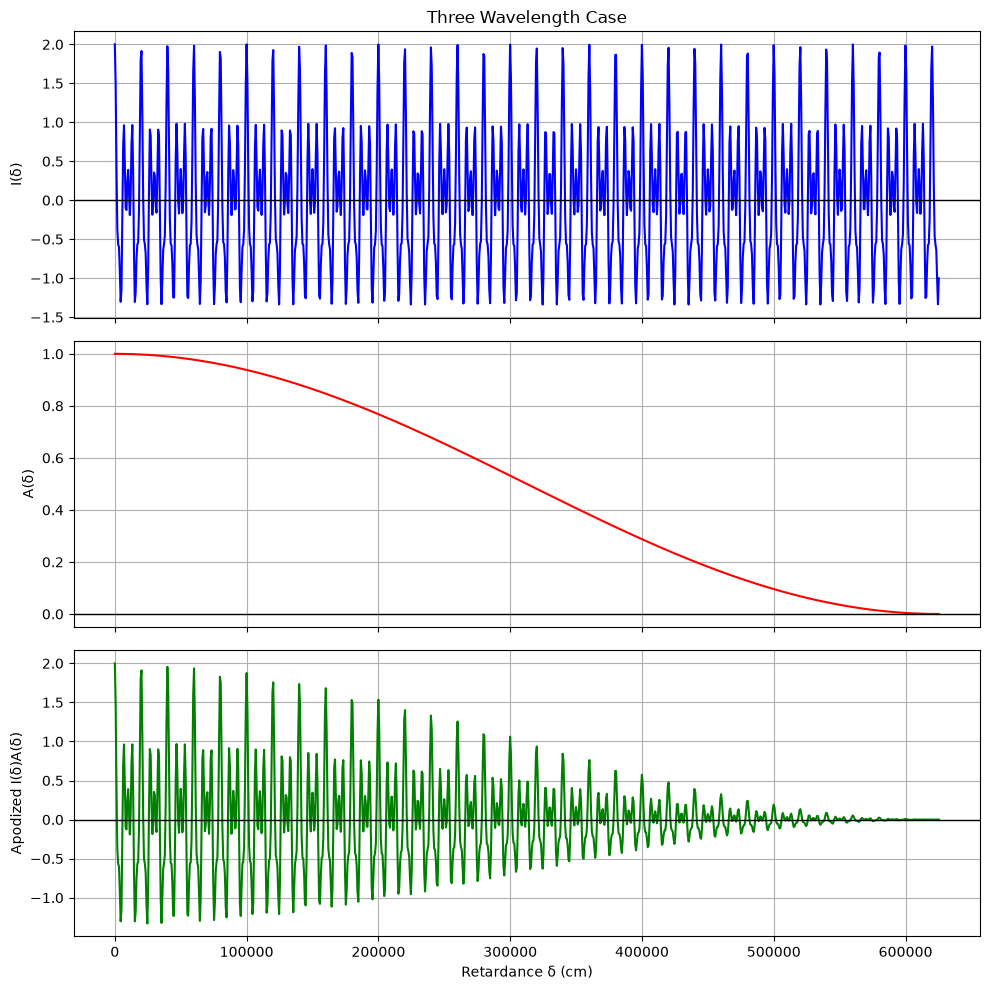

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(deltas * 1e7, I_delta, 'b')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].grid(True)
axes[0].set_ylabel('I(δ)')
axes[0].set_title('Three Wavelength Case')

axes[1].plot(deltas * 1e7, A_delta, 'r')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].grid(True)
axes[1].set_ylabel('A(δ)')

axes[2].plot(deltas * 1e7, Ap_I, 'g')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].grid(True)
axes[2].set_xlabel('Retardance δ (cm)')
axes[2].set_ylabel('Apodized I(δ)A(δ)')

plt.tight_layout()
plt.show()

In [ ]:
# Optional: Compare with single and two-wavelength cases
# The three-wavelength interferogram shows more complex beating patterns
# due to interference between three different frequencies.
# The apodization function remains the same (instrument-dependent only).

### Section 2: Interferograms from real spectra
Here we will start with a real spectrum and construct its interferogram. These spectra come from the 2012 paper cited above. One is for a polystyrene sample, and the other is the blank background.

In [25]:
file_PS = '/content/MSE7530/sampledata/Polystyrene.csv'
file_bg = '/content/MSE7530/sampledata/BackgroundSpectrum.csv'

We use the Pandas package, which we imported as pd, to read the comma separated value files. This package is used very frequently, and can also read excel, text, and more files. It yields a data structure called a **dataframe**, which we won't cover here, but will be very useful.

In [26]:
bg_loaded = pd.read_csv(file_bg,header=0)
PS_loaded = pd.read_csv(file_PS,header=0)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/BackgroundSpectrum.csv'

In [ ]:
# here's what a dataframe looks like
PS_loaded

,Wavenumber,Intensity,DataPoint
0,470.5533,2.418413,1
1,474.4103,2.554376,2
2,478.2673,2.696415,3
3,482.1243,2.790811,4
4,485.9813,2.807886,5
...,...,...,...
704,3185.8780,13.031920,705
705,3189.7350,12.937460,706
706,3193.5920,12.801440,707
707,3197.4490,12.668960,708


Before beginning, let's take a look at the two spectra. I have used Gemini to quickly generate this.

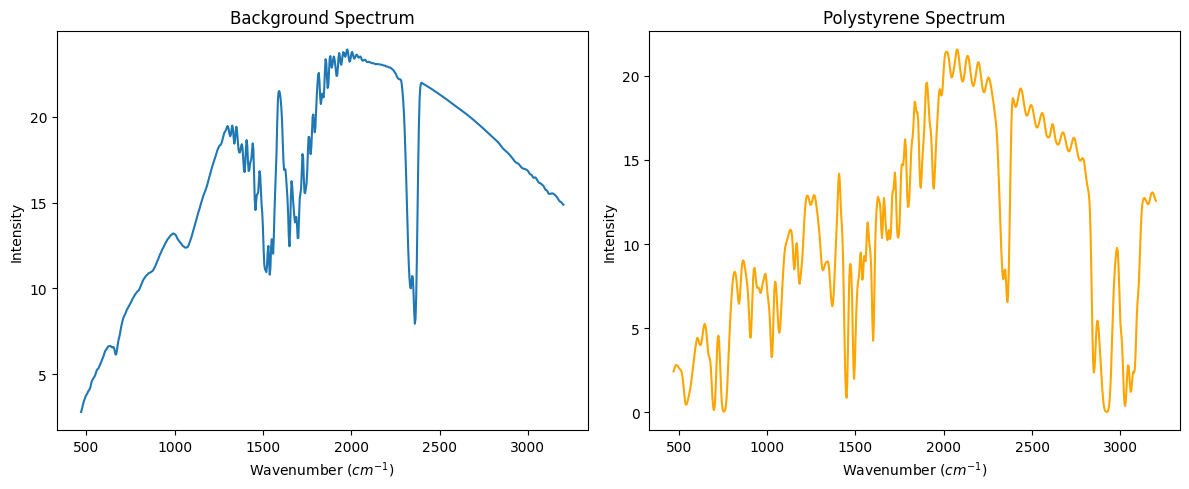

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(bg_loaded['Wavenumber'], bg_loaded['Intensity'])
ax1.set_title('Background Spectrum')
ax1.set_xlabel('Wavenumber ($cm^{-1}$)')
ax1.set_ylabel('Intensity')

ax2.plot(PS_loaded['Wavenumber'], PS_loaded['Intensity'], color='orange')
ax2.set_title('Polystyrene Spectrum')
ax2.set_xlabel('Wavenumber ($cm^{-1}$)')
ax2.set_ylabel('Intensity')

plt.tight_layout()
plt.show()

We are going to use our fundamental principles to go **backwards** from processed data to how the instrument got there.

#### Calculating the interferogram for the Background

Because of that dataframe form, we need to convert the different columns to NumPy arrays as I have done below.

In [ ]:
n_wns = np.asarray(bg_loaded['DataPoint'])
wns_bg = np.asarray(bg_loaded['Wavenumber'])
Is_bg = np.asarray(bg_loaded['Intensity'])

Now we calculate $I(\delta)$ (really, $I(\delta)A(\delta)$) by summing through all of the measurements. The key here is that the spectra that you see above contain all of the $I_{0}$ coefficients for each wavenumber:

In [ ]:
ks = np.linspace(0,988,989)
# note that this is from the instrumental data we had earlier; it is NOT the number of wavenumbers in the processed spectrum
deltas = ks * h_cm

Text(0.5, 1.0, 'Background interferogram')

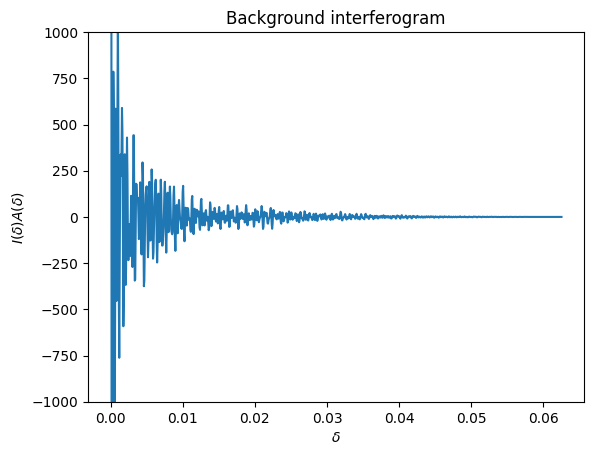

In [ ]:
I_delta_bg = np.zeros(len(deltas)) # initialize somewhere to hold the data
for i in range(len(n_wns)): # goes
  I_delta_bg += Is_bg[i] * np.cos(2 * np.pi * wns_bg[i] * deltas)

A_delta = 0.5 * (1 + np.cos(np.pi * deltas / (ks[-1]*h_cm)))
fig, ax = plt.subplots()
ax.plot(deltas, I_delta_bg*A_delta)
ax.set_ylim(-1000, 1000)
ax.set_ylabel(r'$I(\delta)A(\delta)$')
ax.set_xlabel(r'$\delta$')
ax.set_title('Background interferogram')

For display, I have re-scaled the y-limits which cuts off a bit of the data at very small $\delta$.

#### Calculating the interferogram for the PS

In [ ]:
n_wns = np.asarray(PS_loaded['DataPoint'])
wns_ps = np.asarray(PS_loaded['Wavenumber'])
Is_ps = np.asarray(PS_loaded['Intensity'])

Text(0.5, 1.0, 'PS and Background interferograms')

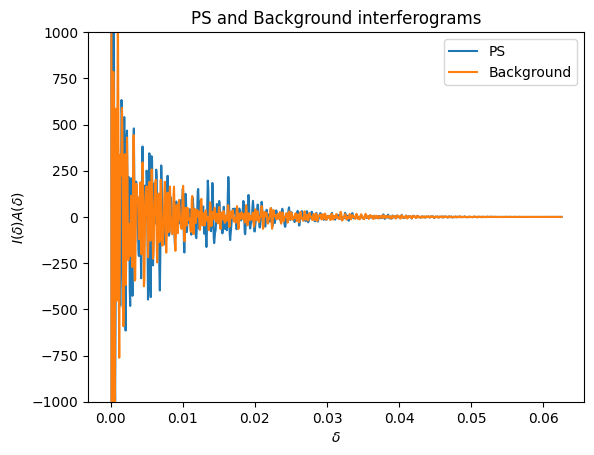

In [ ]:
I_delta_ps = np.zeros(len(deltas))
for i in range(len(n_wns)):
  I_delta_ps += Is_ps[i] * np.cos(2 * np.pi * wns_ps[i] * deltas)

A_delta = 0.5 * (1 + np.cos(np.pi * deltas / (ks[-1]*h_cm)))
fig, ax = plt.subplots()
ax.plot(deltas, I_delta_ps*A_delta,label='PS')
ax.plot(deltas, I_delta_bg*A_delta,label='Background')
ax.legend()
ax.set_ylim(-1000, 1000)
ax.set_ylabel(r'$I(\delta)A(\delta)$')
ax.set_xlabel(r'$\delta$')
ax.set_title('PS and Background interferograms')

These are the signals the spectrometer actually measured.

### Exercise 4: Turning interferograms into spectra
In the previous exercises, we worked backwards from a spectrum (the type you would see in a publication) and made a corresponding interferogram. Now, we will do what the spectrometer does, and turn the measured interferogram into a Spectrum (like you see in a publication).

In [ ]:
1/16

0.0625

To perform a Fourier Transform on an interferogram, **Equation 7** must be solved:  
$B(\bar{\nu}) = \int_{-\infty}^{\infty}I(\delta)A(\delta)cos(2\pi\bar{\nu}\delta \cdotp d\delta)$  
It requires that the retardation $\delta$ must extend from negative to positive infinity. This is impossible, which is why the apodization function needs to be applied.  
<font color='blue'>This apodization function causes the interferogram intensity to decrease in a way that mimics one that extends to infinite retardation. $I(\delta)A(\delta)$ in Equation 7 is the apodized interferogram. </font>

The sampling interval impacts the resolution. The larger the sampling interval, the more information is lost when the interferogram is converted into a spectrum. (Research Nyquist sampling criteria for more information - we won't cover here for now)

The integral presented in equation 7 would be correct for continuous sampling; in reality, we do discrete sampling, so we have a summation rather than an integral as presented in **Equation 8**:  
$B'(\bar{\nu}_1) = I_{a}(0) + 2I_{a}(1)cos(2\pi\bar{\nu_{1}} \cdotp h) + 2I_{a}(2)cos(2\pi\bar{\nu_{1}} \cdotp 2h) + ... + 2I_{a}(N-1)cos(2\pi\bar{\nu_{1}} \cdotp (N-1)h) $

$B'(\bar{\nu}_1) = I_{a}(0) + 2\sum_{k=1}^{N-1}I_{a}(k)cos(2\pi\bar{\nu_{1}} \cdotp kh) $  
Where $k$ is still the measurement number (as in prevous section), $h$ is still the sampling interval determined by the wavelength, and $N$ is still the total number of data points in the interferogram.

### Exercise 1 : Calculate the intensity of a given test wavenumber in an interferogram.

Premise: When we take an interferogram, we are trying to determine what the dominant frequencies that show up in it are. Therefore, we want to see: are there any modes with frequency = x $cm^{-1}$?

First, to illustrate, we will generate an interferogram from a single wavenumber, 1500 $cm^{-1}$ (we did this in the first section, I'm just doing this with our auto-code)

In [27]:
h_cm = 6.328e-5 #cm (from above)
ks = np.linspace(0,988,989)
deltas = ks * h_cm
B_1 = 0.8
wavenumber = 1500 # inv cm
Delta_max = (1/16) * ks[-1] # cm

Text(0.5, 0, 'δ')

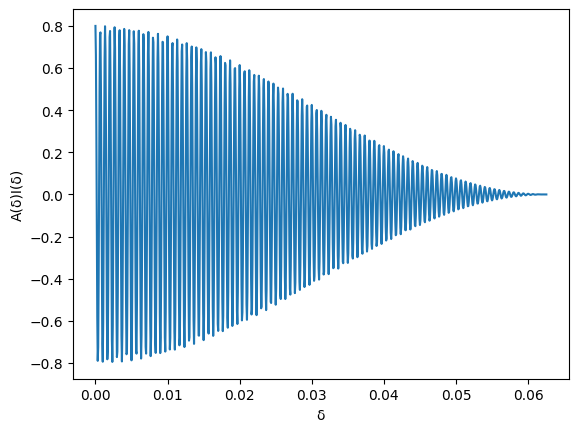

In [ ]:
A_delta = 0.5 * (1 + np.cos(np.pi * deltas / (ks[-1]*h_cm)))
I_delta = B_1 * np.cos(2 * np.pi * 1500 * deltas)
Ap_I_1500 = A_delta * I_delta
fig, ax = plt.subplots()
ax.plot(deltas,Ap_I_1500)
ax.set_ylabel('A(δ)I(δ)')
ax.set_xlabel('δ')

Now, let's say we want to know: Is 2000 $cm^{-1}$ included in this interferogram? You and I know, since we made the interferogram from a 1500 $cm^{-1}$ wavenumber, that it is not. However, we will "try". This is what your analysis code does for each test wavenumber. Here, 2000 $cm^{-1}$ is the "test wavenumber" that we want to find the intensity of.

(0.0, 0.01)

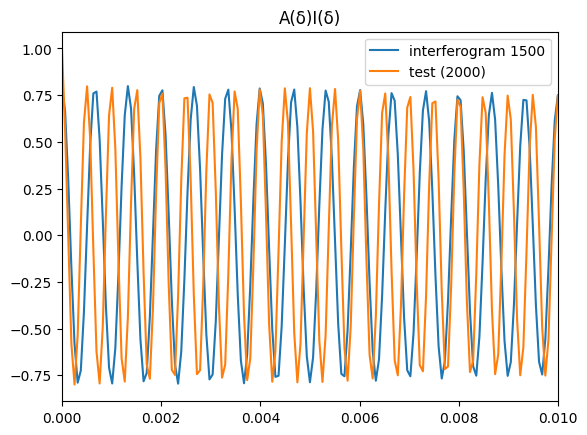

In [ ]:
test_wn = 2000.
I_test = 0.8 * np.cos(2 * np.pi * test_wn * deltas)
I_test[0] = np.cos(2 * np.pi * test_wn * deltas[0])
Ap_I_test = I_test * A_delta
fig, ax = plt.subplots()
ax.plot(deltas,Ap_I_1500,label='interferogram 1500')
ax.plot(deltas,Ap_I_test,label='test (2000)')

#ax.set_xlim(0,0.02)
ax.set_title('A(δ)I(δ)')
ax.legend()
ax.set_xlim(0,0.01)

We have zoomed in to $\delta$ to more closely see the data; it appears that our test wavenumber doesn't appear in the interferogram. We can test it by taking the product of the interferogram and the test wavenumber to see where they coincide. If the frequency is **not** contained in the interferogram, then the sum of this will be 0.

In [ ]:
test_wn = 2000
testing = 2*np.cos(2 * np.pi * test_wn * deltas)
testing[0] = np.cos(2 * np.pi * test_wn * deltas[0])
testing = testing * Ap_I_1500

Here we plot the testing; all 3 plots are the same, they have just been zoomed into different scales for your information.

The sum of the product between the interferogram and the test is -0.0005124727669280071


Text(0.5, 0.98, 'Test * Apodized Interferogram (same data all 3 axes, diff scale)')

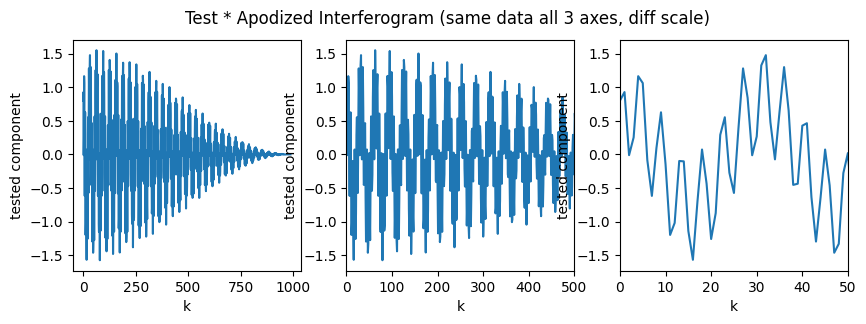

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(10,3))
for a in ax:
  a.plot(testing)
  a.set_xlabel('k')
  a.set_ylabel('tested component')

ax[1].set_xlim(0,500)
ax[2].set_xlim(0,50)
print(f'The sum of the product between the interferogram and the test is {np.sum(testing)}')
plt.suptitle('Test * Apodized Interferogram (same data all 3 axes, diff scale)')

### Testing all wavenumbers for a 3-number spectrum  
Here, we will artificially generate an interferogram that would be expected for a 3-wavenumber measurement. We will then pretend that we don't know what those wavenumbers were and generate an FTIR spectra that will tell us what wavenumbers were present.

In [ ]:
Bs = np.array([0.8,0.5, 0.7])
wns = np.array([1500,3000, 1000])

In [ ]:
# your code here
h_cm = 6.328e-5 #cm (from above)
ks = np.linspace(0,988,989)
deltas = ks * h_cm
# removed the previous single-valued B1 and wavenumber
Delta_max = (1/16) * ks[-1] # cm

Generating the apodized interferogram for our 3-wavenumber case:

In [ ]:
# your code here
I_delta = np.zeros(len(ks))

for i in range(len(Bs)):
  I_delta += Bs[i] * np.cos(2 * np.pi * wns[i] * deltas)
A_delta = 0.5 * (1 + np.cos(np.pi * deltas / (ks[-1]*h_cm))) # wait do I actually sum this up?
Ap_I_3wn = A_delta * I_delta

Now we will generate a set of wavenumbers to test for; the higher resolution you do this, the more well-resolved your spectrum will be.

In [ ]:
wns_to_test = np.linspace(500.,3200.,28)
wns_to_test

array([ 500.,  600.,  700.,  800.,  900., 1000., 1100., 1200., 1300.,
       1400., 1500., 1600., 1700., 1800., 1900., 2000., 2100., 2200.,
       2300., 2400., 2500., 2600., 2700., 2800., 2900., 3000., 3100.,
       3200.])

In [ ]:
# testing = 2*np.cos(2 * np.pi * test_wn * deltas) # except it's not correct for the first one
# testing[0] = np.cos(2 * np.pi * test_wn * deltas[0])
wns_to_test = np.linspace(500.,3200.,28)
rels = np.zeros(len(wns_to_test))
for i in range(len(wns_to_test)):
  testing = 2*np.cos(2 * np.pi * wns_to_test[i] * deltas) # except it's not correct for the first one
  testing[0] = np.cos(2 * np.pi * wns_to_test[i] * deltas[0])
  testing = testing * Ap_I_3wn
  rels[i] = np.sum(testing)

Text(0, 0.5, 'Frequency')

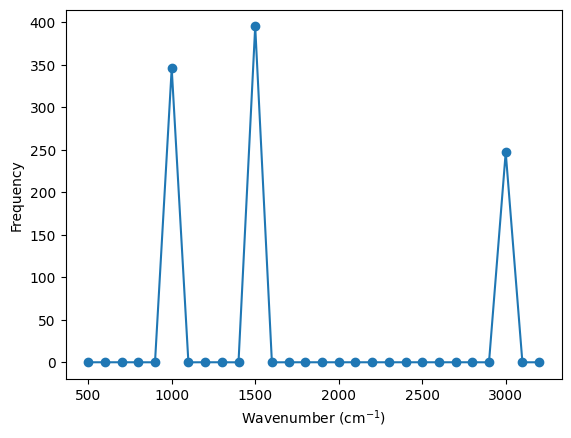

In [ ]:
plt.plot(wns_to_test,rels,'-o')
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Frequency')

Better resolution:

Text(0, 0.5, 'Frequency')

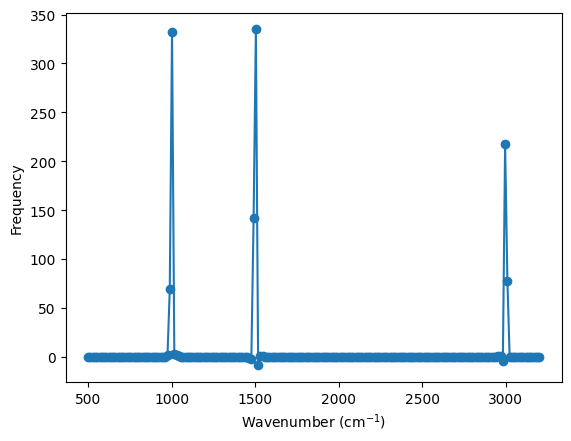

In [ ]:
wns_to_test = np.linspace(500.,3200.,200)
rels = np.zeros(len(wns_to_test))
for i in range(len(wns_to_test)):
  testing = 2*np.cos(2 * np.pi * wns_to_test[i] * deltas) # except it's not correct for the first one
  testing[0] = np.cos(2 * np.pi * wns_to_test[i] * deltas[0])
  testing = testing * Ap_I_3wn
  rels[i] = np.sum(testing)
plt.plot(wns_to_test,rels,'-o')
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Frequency')

### Performing this for a real interferogram

First we re-use our interferograms for polystyrene and the background for the previous exercise.

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_5959/4068787623.py:5: SyntaxWarning: invalid escape sequence '\d'
  ax.set_ylabel('$I(\delta)A(\delta)$')
/tmp/ipykernel_5959/4068787623.py:6: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xlabel('$\delta$')


Text(0.5, 1.0, 'PS and Background interferograms')

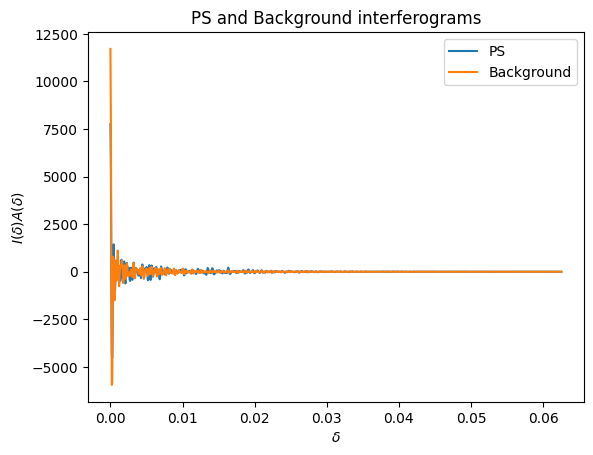

In [ ]:
fig, ax = plt.subplots()
ax.plot(deltas, I_delta_ps*A_delta,label='PS')
ax.plot(deltas, I_delta_bg*A_delta,label='Background')
ax.legend()
ax.set_ylabel('$I(\delta)A(\delta)$')
ax.set_xlabel('$\delta$')
ax.set_title('PS and Background interferograms')

Text(0.5, 1.0, 'Polystyrene spectrum generated from Interferogram')

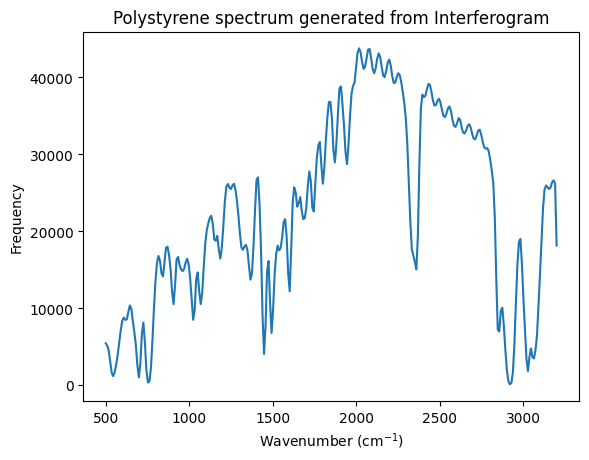

In [ ]:
wns_to_test = np.linspace(500.,3200.,300)
rels = np.zeros(len(wns_to_test))
for i in range(len(wns_to_test)):
  testing = 2*np.cos(2 * np.pi * wns_to_test[i] * deltas) # except it's not correct for the first one
  testing[0] = np.cos(2 * np.pi * wns_to_test[i] * deltas[0])
  testing = testing * I_delta_ps*A_delta
  rels[i] = np.sum(testing)
plt.plot(wns_to_test,rels,'-')
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Frequency')
plt.title('Polystyrene spectrum generated from Interferogram')

Text(0.5, 1.0, 'Background spectrum generated from Interferogram')

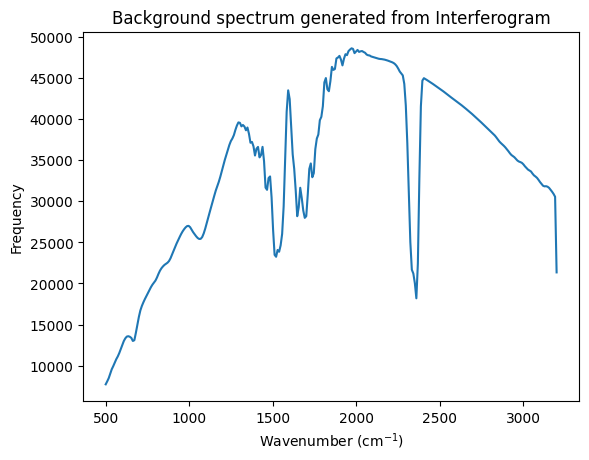

In [ ]:
wns_to_test = np.linspace(500.,3200.,300)
rels = np.zeros(len(wns_to_test))
for i in range(len(wns_to_test)):
  testing = 2*np.cos(2 * np.pi * wns_to_test[i] * deltas) # except it's not correct for the first one
  testing[0] = np.cos(2 * np.pi * wns_to_test[i] * deltas[0])
  testing = testing * I_delta_bg*A_delta
  rels[i] = np.sum(testing)
plt.plot(wns_to_test,rels,'-')
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Frequency')
plt.title('Background spectrum generated from Interferogram')